线性代数与 NDArray

2.1 理论题

In [10]:
import numpy as np

# 1. 向量点积 a·b
a = np.array([2, -1, 3])
b = np.array([1, 4, -2])
dot = np.dot(a, b)
print("1. 向量点积 a·b =", dot)

# 2. 矩阵乘法 A×B
A = np.array([[1, 0, 2],
              [-1, 3, 1]])
B = np.array([[2, 1],
              [0, -1],
              [3, 2]])
AB = A @ B
print("\n2. A×B =")
print(AB)
print("结果形状:", AB.shape)

# 3. 向量a的范数 【修复这里！】
# 向量不能用 'fro'，直接去掉即可
fro_a = np.linalg.norm(a)
print("\n3. a的F范数 =", fro_a)

1. 向量点积 a·b = -8

2. A×B =
[[ 8  5]
 [ 1 -2]]
结果形状: (2, 2)

3. a的F范数 = 3.7416573867739413


2.2 编程题

In [12]:
import numpy as np

# 1. 3×4标准正态随机矩阵X
X = np.random.randn(3, 4)
# 2. 4×2全1矩阵Y
Y = np.ones((4, 2))
# 3. Z = X@Y
Z = X @ Y
# 4. 输出指定位置
print("Z第一行第二列元素：", Z[0, 1])
print("Z第二行所有元素：", Z[1])
# 5. Z的Frobenius范数
print("Z的F范数：", np.linalg.norm(Z, 'fro'))

Z第一行第二列元素： 0.5781890088457209
Z第二行所有元素： [1.24683055 1.24683055]
Z的F范数： 2.069822942400922


3.1 贝叶斯理论题

In [13]:
# 贝叶斯计算代码
P_A = 0.001
P_notA = 0.999
P_B_A = 0.99
P_B_notA = 0.02

P_A_B = (P_B_A * P_A) / (P_B_A * P_A + P_B_notA * P_notA)
print("检测阳性后真实患病概率：", P_A_B)  # ≈0.0472

检测阳性后真实患病概率： 0.047210300429184546


3.2 编程题

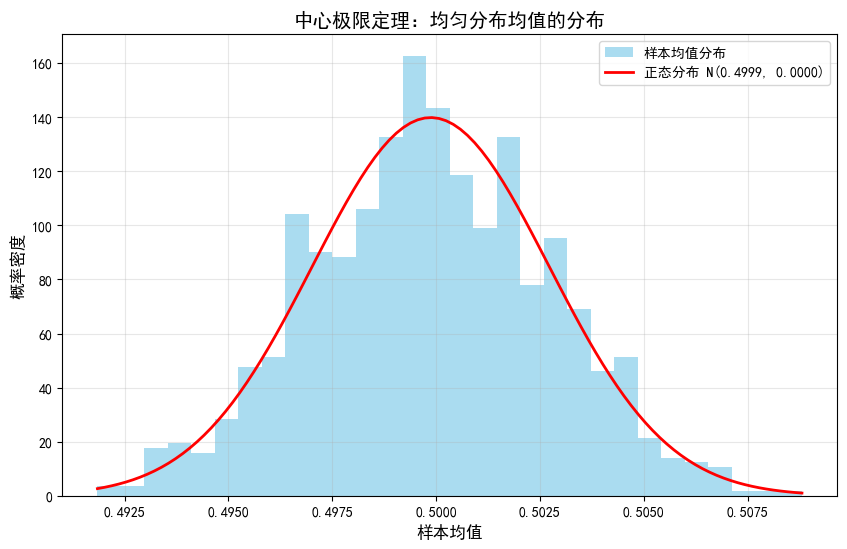

1000个均值的 实际方差 = 0.000008
理论方差（均匀分布）= 1/(12*n) = 0.000008


In [15]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# ====================== 1. 生成数据 ======================
n = 10000    # 每次生成10000个均匀分布样本
m = 1000     # 重复1000次
means = []   # 保存每次的均值

for _ in range(m):
    # 生成 U(0,1) 均匀分布随机数
    samples = np.random.uniform(0, 1, n)
    # 计算均值并保存
    means.append(np.mean(samples))

# ====================== 2. 绘制直方图 + 正态分布曲线 ======================
plt.figure(figsize=(10, 6))

# 绘制均值的直方图（归一化）
plt.hist(means, bins=30, density=True, alpha=0.7, color='skyblue', label='样本均值分布')

# 拟合正态分布
mu, std = norm.fit(means)
x = np.linspace(min(means), max(means), 100)
plt.plot(x, norm.pdf(x, mu, std), 'r-', lw=2, label=f'正态分布 N({mu:.4f}, {std**2:.4f})')

plt.title('中心极限定理：均匀分布均值的分布', fontsize=14)
plt.xlabel('样本均值', fontsize=12)
plt.ylabel('概率密度', fontsize=12)
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# ====================== 3. 计算实际方差 ======================
actual_variance = np.var(means)
print(f"1000个均值的 实际方差 = {actual_variance:.6f}")
print(f"理论方差（均匀分布）= 1/(12*n) = {1/(12*n):.6f}")

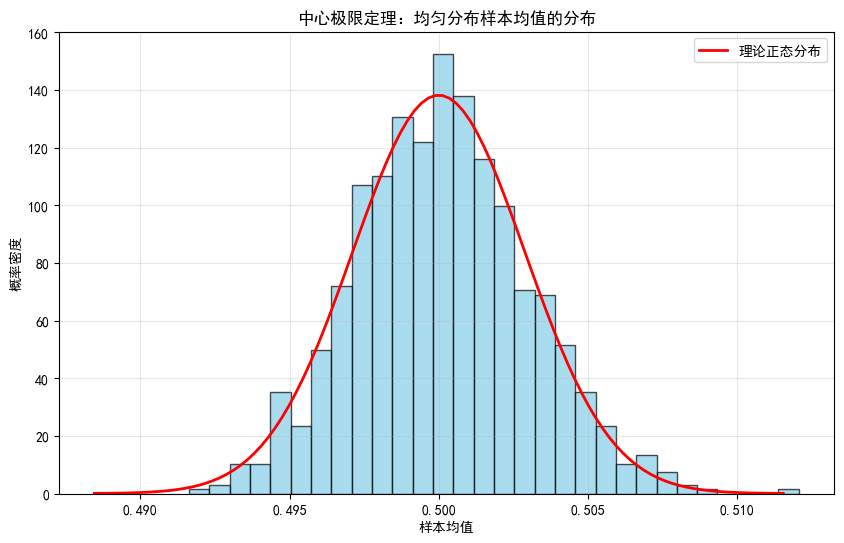

实际方差: 0.000008
理论方差: 0.000008


In [7]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# 参数设置
n = 10000      # 每次采样的样本数
m = 1000       # 重复次数

# 存储每次的样本均值
sample_means = []

for _ in range(m):
    samples = np.random.uniform(0, 1, n)
    sample_means.append(np.mean(samples))

# 绘制直方图
plt.figure(figsize=(10, 6))
plt.hist(sample_means, bins=30, density=True, alpha=0.7, color='skyblue', edgecolor='black')

# 叠加理论正态分布曲线
# 均匀分布 U(0,1) 的均值为 0.5，方差为 1/12
mu = 0.5
sigma = np.sqrt(1/12 / n)  # 均值的标准差 = 总体标准差 / sqrt(n)
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 100)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2, label='理论正态分布')

plt.xlabel('样本均值')
plt.ylabel('概率密度')
plt.title('中心极限定理：均匀分布样本均值的分布')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 计算实际方差
actual_var = np.var(sample_means)
print(f"实际方差: {actual_var:.6f}")
print(f"理论方差: {1/12/n:.6f}")

文档 3：导数、反向传播和复杂度

4.1 理论计算题

In [16]:
# 常数
x1, x2, y = 2, 1, 3
# 变量
w1, w2 = 0.5, 1

# 计算内部项
inner = w1*x1 + w2*x2 - y
# 梯度
dz_dw1 = 2 * x1 * inner
dz_dw2 = 2 * x2 * inner

print("inner =", inner)
print("dz/dw1 =", dz_dw1)
print("dz/dw2 =", dz_dw2)

inner = -1.0
dz/dw1 = -4.0
dz/dw2 = -2.0


4.2 编程题

In [17]:
# 1. 手动实现 前向传播 + 反向传播（链式法则）
x = 2
w1 = 1.5
w2 = 0.5

# 前向计算
a = x * w1
b = a + w2
L = b ** 2

print("===== 手动前向结果 =====")
print(f"a = x*w1 = {a}")
print(f"b = a+w2 = {b}")
print(f"L = b² = {L}\n")

# 手动反向传播（链式法则）
# 梯度公式：
# dL/db = 2b
# db/dw1 = x  ,  db/dw2 = 1
# dL/dw1 = dL/db * db/dw1
# dL/dw2 = dL/db * db/dw2

dL_db = 2 * b
dL_dw1 = dL_db * x
dL_dw2 = dL_db * 1

print("===== 手动梯度结果 =====")
print(f"dL/dw1 = {dL_dw1}")
print(f"dL/dw2 = {dL_dw2}\n")

# 2. PyTorch 自动微分验证
import torch

# 定义需要计算梯度的参数
w1_t = torch.tensor(1.5, requires_grad=True)
w2_t = torch.tensor(0.5, requires_grad=True)
x_t = torch.tensor(2.0)

# 前向
b_t = x_t * w1_t + w2_t
L_t = b_t ** 2

# 反向传播
L_t.backward()

print("===== PyTorch 自动梯度 =====")
print(f"w1.grad = {w1_t.grad.item()}")
print(f"w2.grad = {w2_t.grad.item()}")

===== 手动前向结果 =====
a = x*w1 = 3.0
b = a+w2 = 3.5
L = b² = 12.25

===== 手动梯度结果 =====
dL/dw1 = 14.0
dL/dw2 = 7.0

===== PyTorch 自动梯度 =====
w1.grad = 14.0
w2.grad = 7.0


5.1 理论计算题

In [18]:
import numpy as np

# ===================== 1. 定义数据和参数 =====================
x = np.array([1, 2, 3, 4, 5])  # 特征
y = np.array([2, 4, 6, 8, 10]) # 标签
w = 1  # 初始权重
b = 0  # 初始偏置
n = len(x)

# ===================== 2. 按照推导公式计算偏导数 =====================
# 计算对 b 的偏导：-2/n * Σ(y_i - w*x_i - b)
sum_b = 0
for xi, yi in zip(x, y):
    sum_b += (yi - w * xi - b)
dw_b = -2 / n * sum_b

# 计算对 w 的偏导：-2/n * Σ[ x_i*(y_i - w*x_i - b) ]
sum_w = 0
for xi, yi in zip(x, y):
    sum_w += xi * (yi - w * xi - b)
dw_w = -2 / n * sum_w

# ===================== 3. 输出结果 =====================
print("=== 偏导数计算结果（求和形式推导）===")
print(f"损失对 w 的偏导数 ∂L/∂w = {dw_w:.4f}")
print(f"损失对 b 的偏导数 ∂L/∂b = {dw_b:.4f}")

# ===================== 4. 验证：用向量化计算对比 =====================
y_pred = w * x + b
dw_w_vec = -2 / n * np.sum(x * (y - y_pred))
dw_b_vec = -2 / n * np.sum(y - y_pred)
print("\n=== 向量化验证结果 ===")
print(f"向量化 ∂L/∂w = {dw_w_vec:.4f}")
print(f"向量化 ∂L/∂b = {dw_b_vec:.4f}")

=== 偏导数计算结果（求和形式推导）===
损失对 w 的偏导数 ∂L/∂w = -22.0000
损失对 b 的偏导数 ∂L/∂b = -6.0000

=== 向量化验证结果 ===
向量化 ∂L/∂w = -22.0000
向量化 ∂L/∂b = -6.0000


5.2 编程题

In [19]:
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder

# ===================== 1. 加载数据集 =====================
digits = load_digits()
X = digits.data  # (1797, 64) 8x8展平
y = digits.target.reshape(-1, 1)  # 标签 (1797, 1)

# 划分训练集、测试集 8:2
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ===================== 2. 标签 One-Hot 编码 =====================
encoder = OneHotEncoder(sparse_output=False)
y_train_onehot = encoder.fit_transform(y_train)
y_test_onehot = encoder.transform(y_test)

# 样本数、特征数、类别数
n_samples, n_features = X_train.shape
n_classes = y_train_onehot.shape[1]

# ===================== 3. 初始化参数 =====================
W = np.zeros((n_features, n_classes))  # (64, 10)
b = np.zeros(n_classes)                # (10,)

# ===================== 4. 核心函数实现 =====================
def softmax(z):
    """softmax函数，防止指数溢出"""
    exp_z = np.exp(z - np.max(z, axis=1, keepdims=True))
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

def cross_entropy_loss(y_pred, y_true):
    """交叉熵损失（平均）"""
    n = y_true.shape[0]
    loss = -np.sum(y_true * np.log(y_pred + 1e-8)) / n
    return loss

def forward(X, W, b):
    """前向传播"""
    z = X @ W + b
    return softmax(z)

def gradients(X, y_pred, y_true):
    """损失对 W、b 的梯度（从零推导）"""
    n = X.shape[0]
    dW = X.T @ (y_pred - y_true) / n
    db = np.sum(y_pred - y_true, axis=0) / n
    return dW, db

# ===================== 5. 超参数 =====================
batch_size = 32
lr = 0.1
epochs = 50

# ===================== 6. 小批量梯度下降训练 =====================
print("=== 开始训练 ===")
n_batches = n_samples // batch_size

for epoch in range(epochs):
    # 打乱数据
    indices = np.arange(n_samples)
    np.random.shuffle(indices)
    X_shuffled = X_train[indices]
    y_shuffled = y_train_onehot[indices]

    total_loss = 0.0
    for i in range(n_batches):
        # 取一个小批量
        X_batch = X_shuffled[i*batch_size : (i+1)*batch_size]
        y_batch = y_shuffled[i*batch_size : (i+1)*batch_size]

        # 前向 + 损失 + 梯度
        y_pred = forward(X_batch, W, b)
        loss = cross_entropy_loss(y_pred, y_batch)
        dW, db = gradients(X_batch, y_pred, y_batch)

        # 更新参数
        W -= lr * dW
        b -= lr * db

        total_loss += loss

    # 每轮输出损失
    avg_loss = total_loss / n_batches
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

# ===================== 7. 测试集准确率 =====================
def accuracy(X, y_true, W, b):
    y_pred = forward(X, W, b)
    y_pred_class = np.argmax(y_pred, axis=1)
    y_true_class = np.argmax(y_true, axis=1)
    return np.mean(y_pred_class == y_true_class)

test_acc = accuracy(X_test, y_test_onehot, W, b)
print("\n=== 最终结果 ===")
print(f"测试集准确率: {test_acc:.4f}")

=== 开始训练 ===
Epoch [10/50], Loss: 0.3566
Epoch [20/50], Loss: 0.1220
Epoch [30/50], Loss: 0.1567
Epoch [40/50], Loss: 0.0196
Epoch [50/50], Loss: 0.0002

=== 最终结果 ===
测试集准确率: 0.9750


6.2 编程题

C:\Users\xx\AppData\Local\Temp\ipykernel_32604\2644530382.py:26: RuntimeWarning: overflow encountered in exp
  return 1 / (1 + np.exp(-z))


Iteration 200, Train Accuracy: 0.8067
Iteration 400, Train Accuracy: 0.8067
Iteration 600, Train Accuracy: 0.8067
Iteration 800, Train Accuracy: 0.8067
Iteration 1000, Train Accuracy: 0.8067

测试集准确率: 78.00%


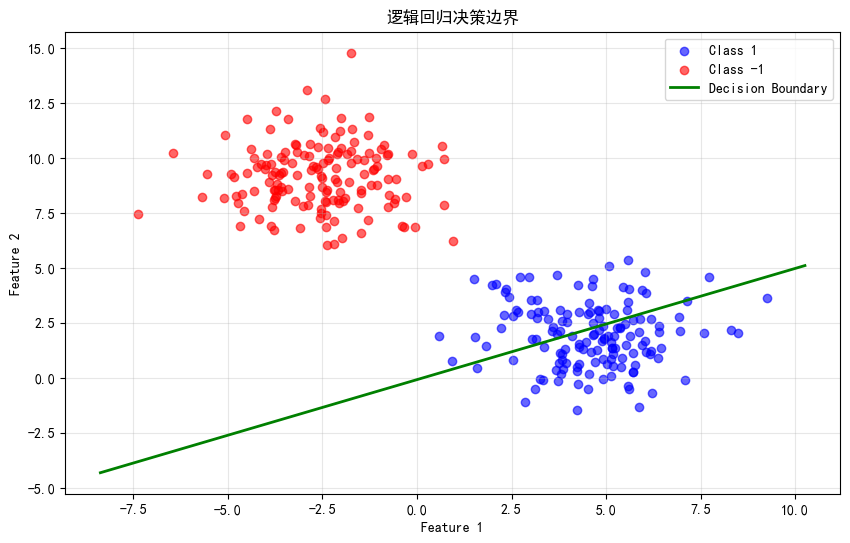

In [6]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'DejaVu Sans']
matplotlib.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# 生成线性可分数据
X, y = make_blobs(n_samples=400, n_features=2, centers=2, cluster_std=1.5, random_state=42)
y = y * 2 - 1  # 将标签转为 -1 和 1，方便后续公式

# 划分训练集和测试集
X_train, y_train = X[:300], y[:300]
X_test, y_test = X[300:], y[300:]

# 参数初始化
w = np.zeros(2)
b = 0.0
lr = 0.1
iterations = 1000

# Sigmoid 函数
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# 二元交叉熵损失和梯度
def compute_gradients(X, y, w, b):
    m = X.shape[0]
    linear = X @ w + b
    y_pred = sigmoid(linear)
    dw = (X.T @ (y_pred - y)) / m
    db = np.mean(y_pred - y)
    return dw, db

# 梯度下降训练
for i in range(iterations):
    dw, db = compute_gradients(X_train, y_train, w, b)
    w -= lr * dw
    b -= lr * db
    
    if (i + 1) % 200 == 0:
        y_pred_train = sigmoid(X_train @ w + b) >= 0.5
        train_acc = np.mean(y_pred_train == (y_train == 1))
        print(f"Iteration {i+1}, Train Accuracy: {train_acc:.4f}")

# 测试准确率
y_pred_test = sigmoid(X_test @ w + b) >= 0.5
test_acc = np.mean(y_pred_test == (y_test == 1))
print(f"\n测试集准确率: {test_acc * 100:.2f}%")

# 绘制决策边界
plt.figure(figsize=(10, 6))
plt.scatter(X_train[y_train == 1][:, 0], X_train[y_train == 1][:, 1], c='blue', label='Class 1', alpha=0.6)
plt.scatter(X_train[y_train == -1][:, 0], X_train[y_train == -1][:, 1], c='red', label='Class -1', alpha=0.6)

# 绘制决策边界: w0*x + w1*y + b = 0
x_boundary = np.array([X[:, 0].min() - 1, X[:, 0].max() + 1])
y_boundary = -(w[0] * x_boundary + b) / w[1]
plt.plot(x_boundary, y_boundary, 'g-', linewidth=2, label='Decision Boundary')

plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('逻辑回归决策边界')
plt.legend()
plt.grid(alpha=0.3)
plt.show()